In [1]:
import numpy as np
from matplotlib import pyplot as plt
import h5py

In [2]:
label_size = 24

tick_size = 20
legend_size = 20

lw = 1.5

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]
plt.rcParams["axes.linewidth"] = 0.8

In [3]:
def compute_L2_and_next_moment_abs_error(filename):
    with h5py.File(filename, "r") as f:
        
        keys = list(f.keys())
        mo_next = [x[11:] for x in keys if x.startswith("ref_M_test_")]
        
        sparsity_degree = f["sparsity_degree"][:]
        # print(mo_next)
        l1_moment_errors = [sum([abs(f[f"predicted_M_{x}"][:][i] - f[f"ref_M_test_{x}"])  for x in mo_next])
                            for i in range(len(sparsity_degree))]
        
        ref_vdf = f["vdf_hidden_truth"][:]
        predictions = f["solutions"][:]
        w = f["weighting_function"][:]
        
        errors_vdf_L2 = [np.sqrt(np.sum((predictions[i,:,:,:] * w - ref_vdf)**2)) for i in range(len(sparsity_degree))]
        
        l2_ref_vdf = np.sqrt(np.sum(ref_vdf)**2)
    return sparsity_degree, l1_moment_errors, errors_vdf_L2, l2_ref_vdf

In [14]:
def plot_L2_and_next_errors(path_to_dir, output_path, vdf_name, n_v, m1, m2, dof_rel=True):

    path_M1 = f"{path_to_dir}/{vdf_name}_constraint_M_upto{m1}_{n_v}.h5"
    path_M2 = f"{path_to_dir}/{vdf_name}_constraint_M_upto{m2}_{n_v}.h5"
    data1 = compute_L2_and_next_moment_abs_error(path_M1)
    data2 = compute_L2_and_next_moment_abs_error(path_M2)
    
    dofs1 = [n_v**3 - x for x in data1[0]]
    dofs2 = [n_v**3 - x for x in data2[0]]
    
    mind = min([min(dofs1), min(dofs2)])
    maxd = max([max(dofs1), max(dofs2)])
    
    xl = [mind-300, maxd+300]
    
    if dof_rel:
        dofs1 = [100 * x/n_v**3 for x in dofs1]
        dofs2 = [100 * x/n_v**3 for x in dofs2]
        xl = [100 * x/n_v**3 for x in xl]
    
    fig = plt.figure(figsize=(18,6))

    ax1 = fig.add_subplot(1,2,1)
    ax1.plot(dofs1, [x/data1[3] for x in data1[2]], '-o', label=r"$m_{\mathrm{max}} = " + f"{m1}$", linewidth=lw)
    ax1.plot(dofs2, [x/data2[3] for x in data2[2]], '-o', label=r"$m_{\mathrm{max}} = " + f"{m2}$", linewidth=lw)
    
    ax2 = fig.add_subplot(1,2,2)
    ax2.plot(dofs1, data1[1], '-o', linewidth=lw)
    ax2.plot(dofs2, data2[1], '-o', linewidth=lw)
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    
    
    ax1.legend(fontsize=legend_size, frameon=False, loc="best")

    for ax in [ax1, ax2]:
        ax.grid(":")
        ax.tick_params(axis='both', labelsize=tick_size)
        if dof_rel:
            ax.set_xlabel("\% of D.o.F.", fontsize=label_size)
        else:
            ax.set_xlabel("D.o.F.", fontsize=label_size)
        ax.set_xlim(xl)
        
    ax1.set_ylabel(r"$\frac{||f_{\mathrm{pred}} - f_{\mathrm{true}}||_2}{||f_{\mathrm{true}}||_2}$", fontsize=label_size)
    ax2.set_ylabel(r"$E_{m_{\mathrm{max}+1}}$", fontsize=label_size)
    # if err_rel_abs_list[plot_index] == "a":
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$", fontsize=label_size)
    # else:
    #     ax.set_ylabel(r"$\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true} - M_{i,j}^{pred}|$ / $\sum_{i+j=" + f"{m_constraint+1}" + "} |M_{i,j}^{true}|$", fontsize=label_size)

    # ax.set_xlim([min(dofs), int(nv)**2])

    fig.savefig(f"{output_path}/{vdf_name}_{n_v}_errors_{m1}_{m2}.pdf", bbox_inches="tight")

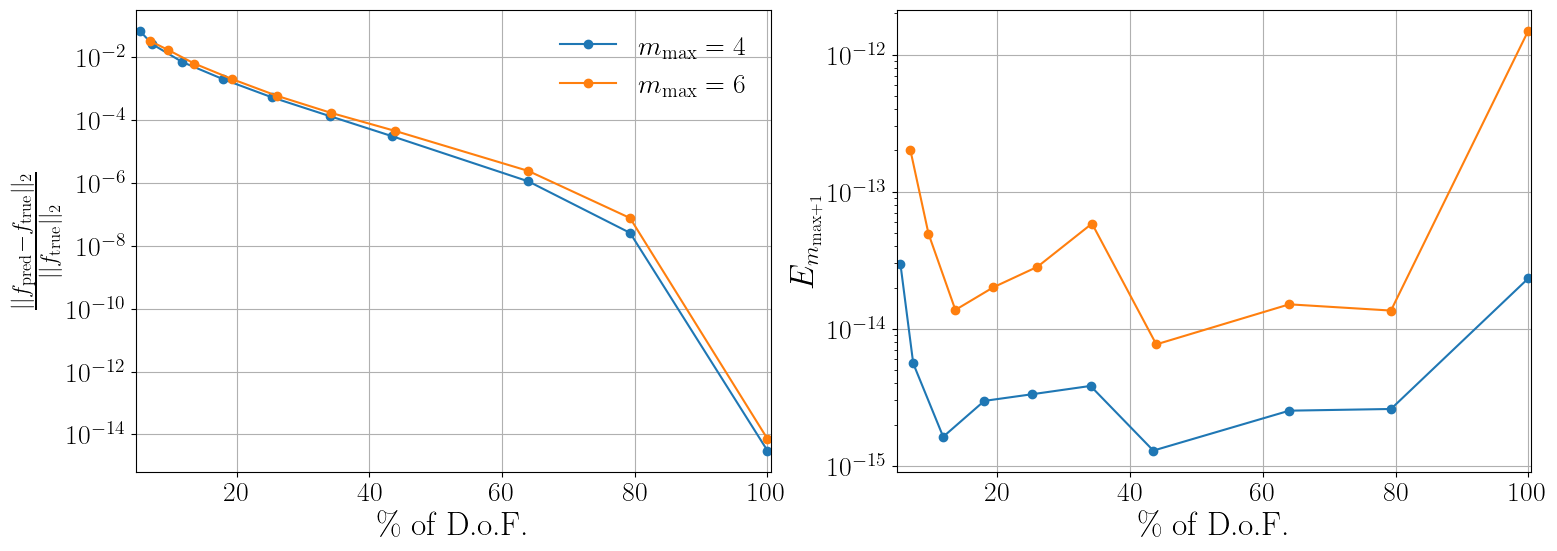

In [15]:
plot_L2_and_next_errors("../../output", "../../plots", "Maxwell_Boltzmann", 40, 4, 6, dof_rel=True)

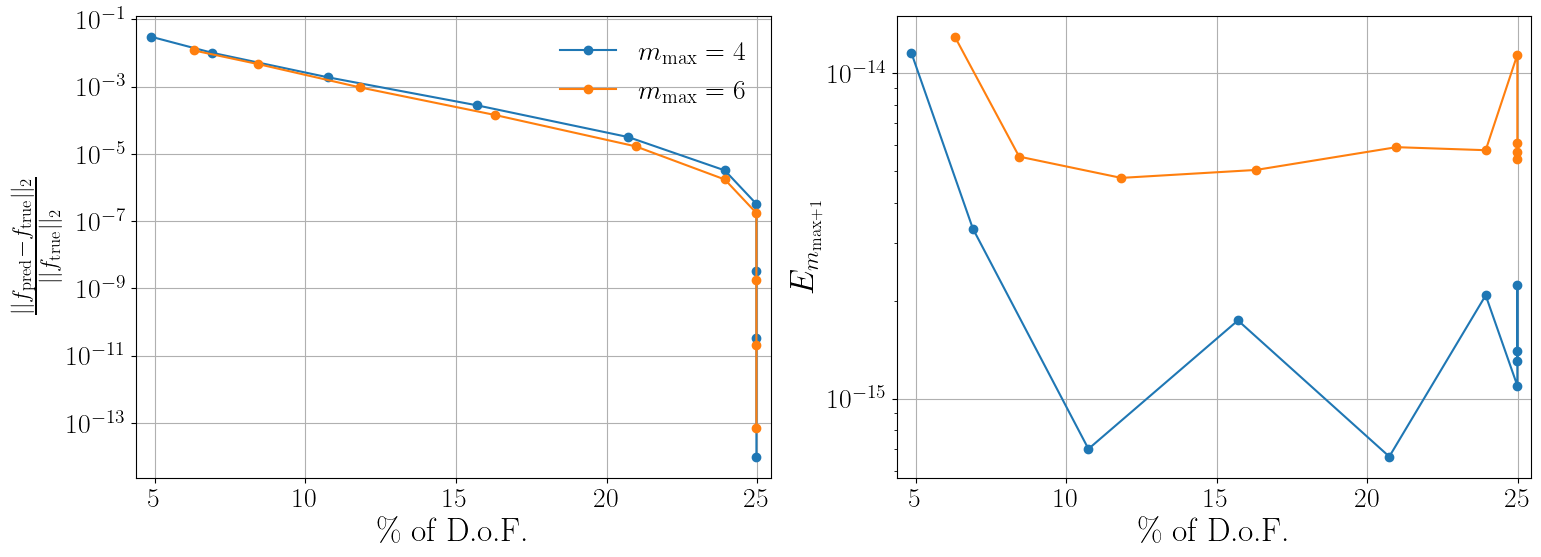

In [16]:
plot_L2_and_next_errors("../../output", "../../plots", "Druyvesteyn", 40, 4, 6, dof_rel=True)

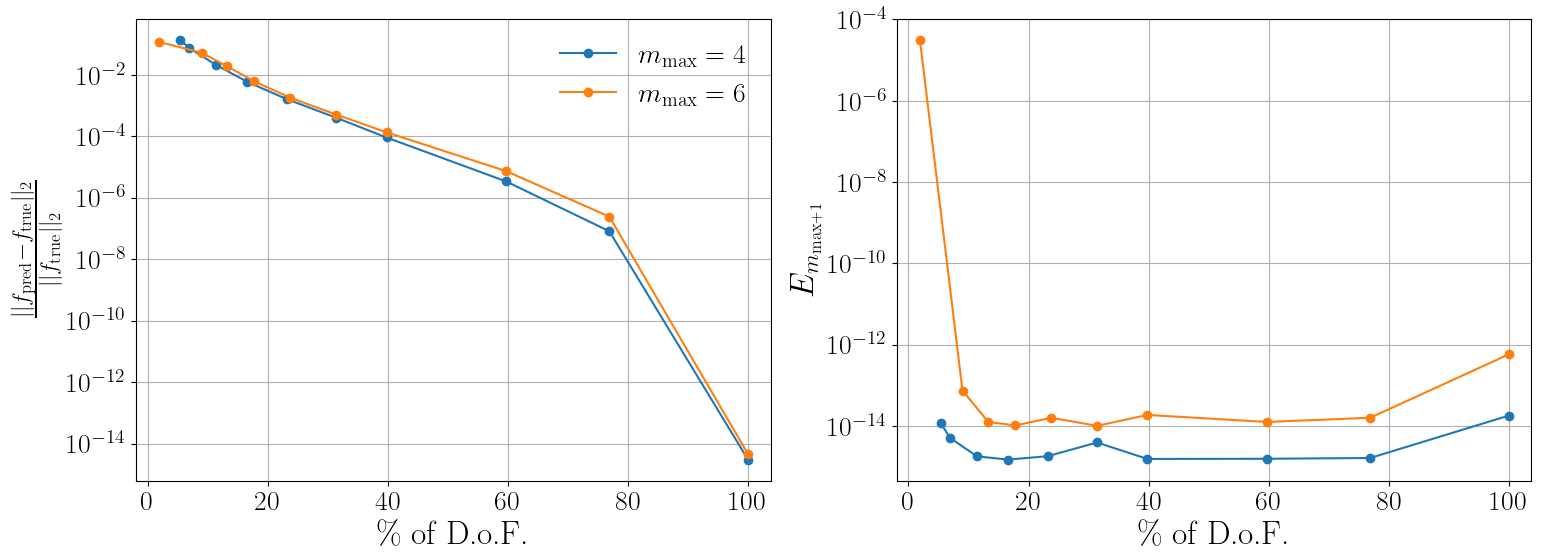

In [17]:
plot_L2_and_next_errors("../../output", "../../plots", "Maxwell_Boltzmann", 20, 4, 6, dof_rel=True)

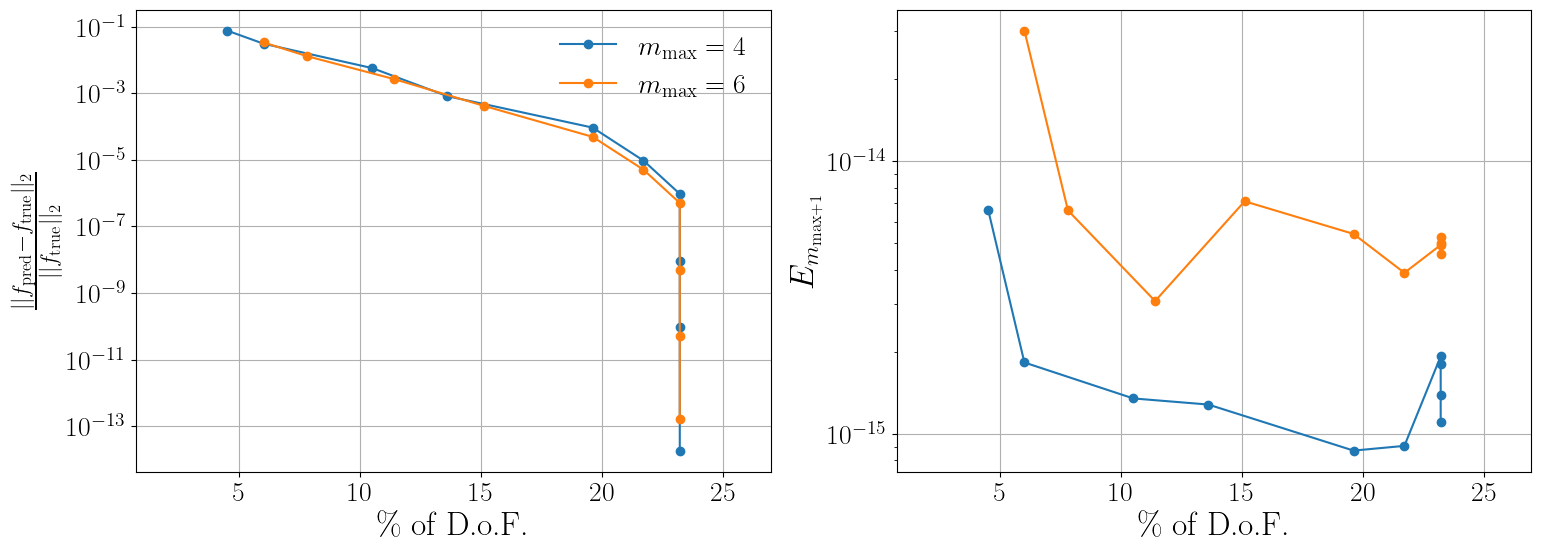

In [18]:
plot_L2_and_next_errors("../../output", "../../plots", "Druyvesteyn", 20, 4, 6, dof_rel=True)